# Ejercicio 12: Multimodal Embeddings

### Nombre: Anthony Goyes

## Objetivo de la práctica

El objetivo de este ejercicio es observar cómo modelos multimodales como CLIP llevan texto e imágenes al mismo espacio vectorial, y verificar graficando embeddings en 2D.

### Pasos:

1. Obtener embeddings de imágenes y textos con CLIP.
2. Mostrar que ambos viven en el mismo espacio (misma dimensión y comparables).
3. Proyectar los vectores a 2D (PCA / t-SNE / UMAP) y graficarlos en un plano.
4. Verificar emparejamientos usando cosine similarity (búsqueda texto→imagen e imagen→texto).

### Instalación de librerías

In [1]:
%pip install transformers torch pillow scikit-learn matplotlib scikit-image

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   --- ------------------------------------ 1.0/11.9 MB 4.8 MB/s eta 0:00:03
   --------- ------------------------------ 2.9/11.9 MB 6.1 MB/s eta 0:00:02
   --------------- ------------------------ 4.7/11.9 MB 7.1 MB/s eta 0:00:02
   --------------------- ------------------ 6.3/11.9 MB 7.5 MB/s eta 0:00:01
   ---------------------------- ----------- 8.4/11.9 MB 7.5 MB/s eta 0:00:01
   ---------------------------------- ----- 10.2/11.9 MB 7.7 MB/s eta 0:00:01
   ---------------------------------------  11.8/11.9 MB 7.7 MB/s eta 0:00:01
   ---------------------------------------- 11.9/11.9 MB 7.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Importar librerías

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from pathlib import Path

from transformers import CLIPProcessor, CLIPModel

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

from skimage import data

### Crear un pequeño conjunto de imágenes y textos

In [2]:
output_dir = Path("../data/multimodal_images")
output_dir.mkdir(parents=True, exist_ok=True)

image_data = [
    {
        "id": "astronaut",
        "image": Image.fromarray(data.astronaut()),
        "text": "a photo of an astronaut"
    },
    {
        "id": "cat",
        "image": Image.fromarray(data.chelsea()),
        "text": "a photo of a cat"
    },
    {
        "id": "coffee",
        "image": Image.fromarray(data.coffee()),
        "text": "a photo of a cup of coffee"
    },
    {
        "id": "rocket",
        "image": Image.fromarray(data.rocket()),
        "text": "a photo of a rocket"
    },
    {
        "id": "camera",
        "image": Image.fromarray(data.camera()).convert("RGB"),
        "text": "a photo of a camera"
    },
    {
        "id": "horse",
        "image": Image.fromarray(data.horse()).convert("RGB"),
        "text": "a photo of a horse"
    }
]

for item in image_data:
    image_path = output_dir / f"{item['id']}.png"
    item["image"].save(image_path)
    item["path"] = str(image_path)

print("Total de imágenes:", len(image_data))

for item in image_data:
    print(item["id"], "->", item["text"])

Total de imágenes: 6
astronaut -> a photo of an astronaut
cat -> a photo of a cat
coffee -> a photo of a cup of coffee
rocket -> a photo of a rocket
camera -> a photo of a camera
horse -> a photo of a horse


### Visualizar las imágenes

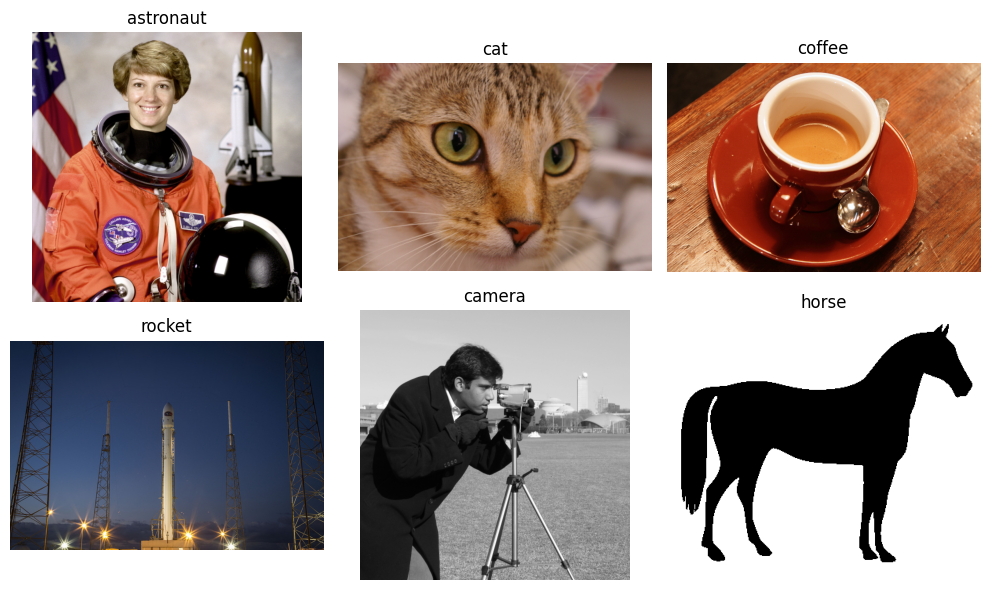

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

for ax, item in zip(axes.flatten(), image_data):
    ax.imshow(item["image"])
    ax.set_title(item["id"])
    ax.axis("off")

plt.tight_layout()
plt.show()

### Cargar modelo CLIP

In [4]:
model_name = "openai/clip-vit-base-patch32"

device = "cuda" if torch.cuda.is_available() else "cpu"

model = CLIPModel.from_pretrained(model_name).to(device)
processor = CLIPProcessor.from_pretrained(model_name)

print("Modelo cargado:", model_name)
print("Dispositivo:", device)

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

C:\Users\Anthony\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Anthony\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Modelo cargado: openai/clip-vit-base-patch32
Dispositivo: cpu


### Obtener embeddings de imágenes y textos

In [5]:
images = [item["image"] for item in image_data]
texts = [item["text"] for item in image_data]

inputs = processor(
    text=texts,
    images=images,
    return_tensors="pt",
    padding=True
).to(device)

with torch.no_grad():
    outputs = model(**inputs)

image_embeddings = outputs.image_embeds
text_embeddings = outputs.text_embeds

print("Shape embeddings de imágenes:", image_embeddings.shape)
print("Shape embeddings de textos:", text_embeddings.shape)

Shape embeddings de imágenes: torch.Size([6, 512])
Shape embeddings de textos: torch.Size([6, 512])


### Normalizar embeddings

In [6]:
image_embeddings = image_embeddings / image_embeddings.norm(dim=-1, keepdim=True)
text_embeddings = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)

image_embeddings_np = image_embeddings.cpu().numpy()
text_embeddings_np = text_embeddings.cpu().numpy()

print("Embeddings de imágenes:", image_embeddings_np.shape)
print("Embeddings de textos:", text_embeddings_np.shape)

Embeddings de imágenes: (6, 512)
Embeddings de textos: (6, 512)


### Calcular similitud coseno texto → imagen

In [7]:
similarity_matrix = cosine_similarity(text_embeddings_np, image_embeddings_np)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=[f"Text: {item['id']}" for item in image_data],
    columns=[f"Image: {item['id']}" for item in image_data]
)

similarity_df

,Image: astronaut,Image: cat,Image: coffee,Image: rocket,Image: camera,Image: horse
Text: astronaut,0.269597,0.213072,0.187699,0.230660,0.222050,0.200132
Text: cat,0.155361,0.282686,0.201332,0.169625,0.213218,0.228718
Text: coffee,0.149645,0.204157,0.302018,0.148795,0.192418,0.189972
Text: rocket,0.198302,0.213632,0.181791,0.284391,0.219044,0.203874
Text: camera,0.172076,0.219409,0.205535,0.194457,0.273031,0.208196
Text: horse,0.169319,0.210601,0.199641,0.187600,0.210242,0.317865


### Visualizar matriz de similitud

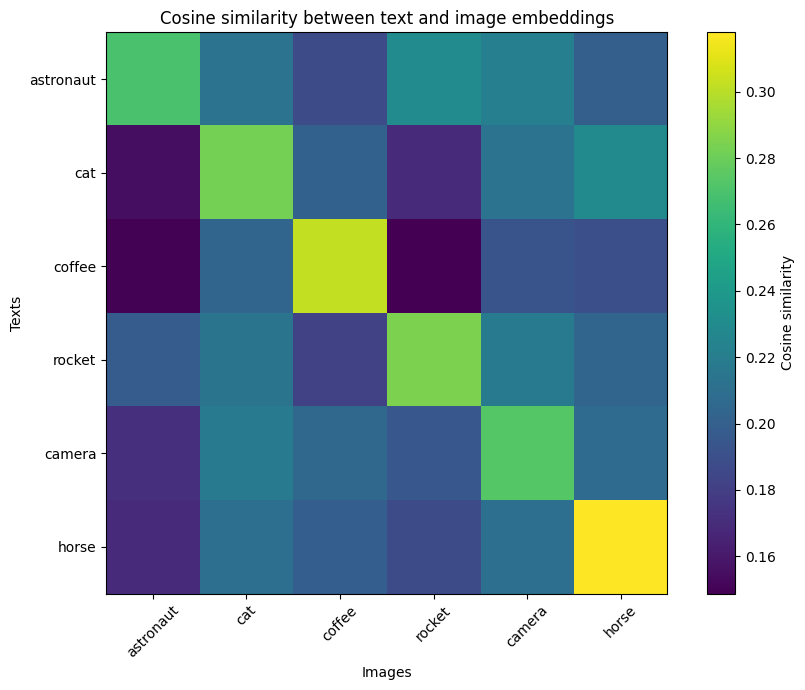

In [8]:
plt.figure(figsize=(9, 7))
plt.imshow(similarity_matrix)
plt.colorbar(label="Cosine similarity")

plt.xticks(
    ticks=range(len(image_data)),
    labels=[item["id"] for item in image_data],
    rotation=45
)

plt.yticks(
    ticks=range(len(image_data)),
    labels=[item["id"] for item in image_data]
)

plt.xlabel("Images")
plt.ylabel("Texts")
plt.title("Cosine similarity between text and image embeddings")

plt.tight_layout()
plt.show()

### Búsqueda texto → imagen

In [9]:
text_to_image_results = []

for text_idx, text_item in enumerate(image_data):
    similarities = similarity_matrix[text_idx]
    best_image_idx = np.argmax(similarities)
    
    text_to_image_results.append({
        "query_text": text_item["text"],
        "expected_image": text_item["id"],
        "retrieved_image": image_data[best_image_idx]["id"],
        "similarity": similarities[best_image_idx],
        "correct": text_item["id"] == image_data[best_image_idx]["id"]
    })

text_to_image_df = pd.DataFrame(text_to_image_results)
text_to_image_df

,query_text,expected_image,retrieved_image,similarity,correct
0,a photo of an astronaut,astronaut,astronaut,0.269597,True
1,a photo of a cat,cat,cat,0.282686,True
2,a photo of a cup of coffee,coffee,coffee,0.302018,True
3,a photo of a rocket,rocket,rocket,0.284391,True
4,a photo of a camera,camera,camera,0.273031,True
5,a photo of a horse,horse,horse,0.317865,True


### Búsqueda imagen → texto

In [10]:
image_to_text_results = []

for image_idx, image_item in enumerate(image_data):
    similarities = similarity_matrix[:, image_idx]
    best_text_idx = np.argmax(similarities)
    
    image_to_text_results.append({
        "query_image": image_item["id"],
        "expected_text": image_item["text"],
        "retrieved_text": image_data[best_text_idx]["text"],
        "similarity": similarities[best_text_idx],
        "correct": image_item["id"] == image_data[best_text_idx]["id"]
    })

image_to_text_df = pd.DataFrame(image_to_text_results)
image_to_text_df

,query_image,expected_text,retrieved_text,similarity,correct
0,astronaut,a photo of an astronaut,a photo of an astronaut,0.269597,True
1,cat,a photo of a cat,a photo of a cat,0.282686,True
2,coffee,a photo of a cup of coffee,a photo of a cup of coffee,0.302018,True
3,rocket,a photo of a rocket,a photo of a rocket,0.284391,True
4,camera,a photo of a camera,a photo of a camera,0.273031,True
5,horse,a photo of a horse,a photo of a horse,0.317865,True


### Proyectar embeddings a 2D con PCA

In [11]:
all_embeddings = np.vstack([image_embeddings_np, text_embeddings_np])

labels = [item["id"] for item in image_data] + [item["id"] for item in image_data]
types = ["image"] * len(image_data) + ["text"] * len(image_data)

pca = PCA(n_components=2)
embeddings_2d_pca = pca.fit_transform(all_embeddings)

pca_df = pd.DataFrame({
    "x": embeddings_2d_pca[:, 0],
    "y": embeddings_2d_pca[:, 1],
    "label": labels,
    "type": types
})

pca_df

,x,y,label,type
0,-0.459298,-0.600978,astronaut,image
1,-0.525950,0.316598,cat,image
2,-0.516408,0.373334,coffee,image
3,-0.496204,-0.437294,rocket,image
4,-0.520813,0.100430,camera,image
5,-0.512884,0.205123,horse,image
6,0.496176,-0.114669,astronaut,text
7,0.523999,0.073619,cat,text
8,0.488585,0.109645,coffee,text
9,0.494601,-0.092620,rocket,text


### Graficar PCA 2D

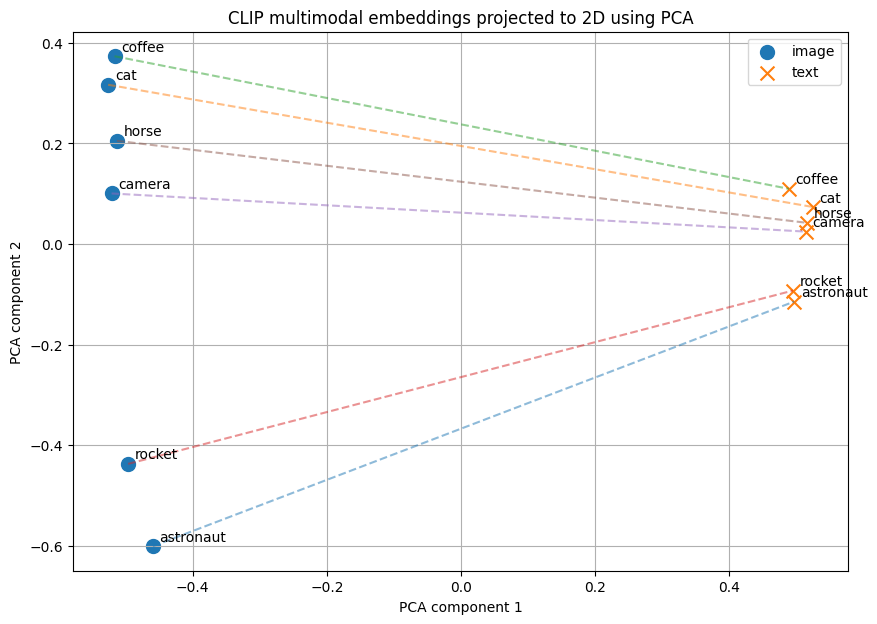

In [12]:
plt.figure(figsize=(10, 7))

for item_type, marker in [("image", "o"), ("text", "x")]:
    subset = pca_df[pca_df["type"] == item_type]
    
    plt.scatter(
        subset["x"],
        subset["y"],
        marker=marker,
        s=100,
        label=item_type
    )
    
    for _, row in subset.iterrows():
        plt.text(row["x"] + 0.01, row["y"] + 0.01, row["label"])

# Dibujar líneas entre cada imagen y su texto correspondiente
for i in range(len(image_data)):
    image_point = pca_df.iloc[i]
    text_point = pca_df.iloc[i + len(image_data)]
    
    plt.plot(
        [image_point["x"], text_point["x"]],
        [image_point["y"], text_point["y"]],
        linestyle="--",
        alpha=0.5
    )

plt.title("CLIP multimodal embeddings projected to 2D using PCA")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.legend()
plt.grid(True)
plt.show()

### Proyección opcional con t-SNE

In [13]:
tsne = TSNE(
    n_components=2,
    perplexity=3,
    random_state=42,
    init="random",
    learning_rate="auto"
)

embeddings_2d_tsne = tsne.fit_transform(all_embeddings)

tsne_df = pd.DataFrame({
    "x": embeddings_2d_tsne[:, 0],
    "y": embeddings_2d_tsne[:, 1],
    "label": labels,
    "type": types
})

tsne_df

,x,y,label,type
0,-19.854776,-85.764671,astronaut,image
1,-29.942137,-105.633087,cat,image
2,-27.512098,-110.612946,coffee,image
3,-18.073313,-90.510582,rocket,image
4,-23.009628,-103.624512,camera,image
5,-33.895355,-101.282875,horse,image
6,-2.137763,80.844765,astronaut,text
7,-13.204310,86.739761,cat,text
8,-23.378059,88.483223,coffee,text
9,1.214408,85.128242,rocket,text


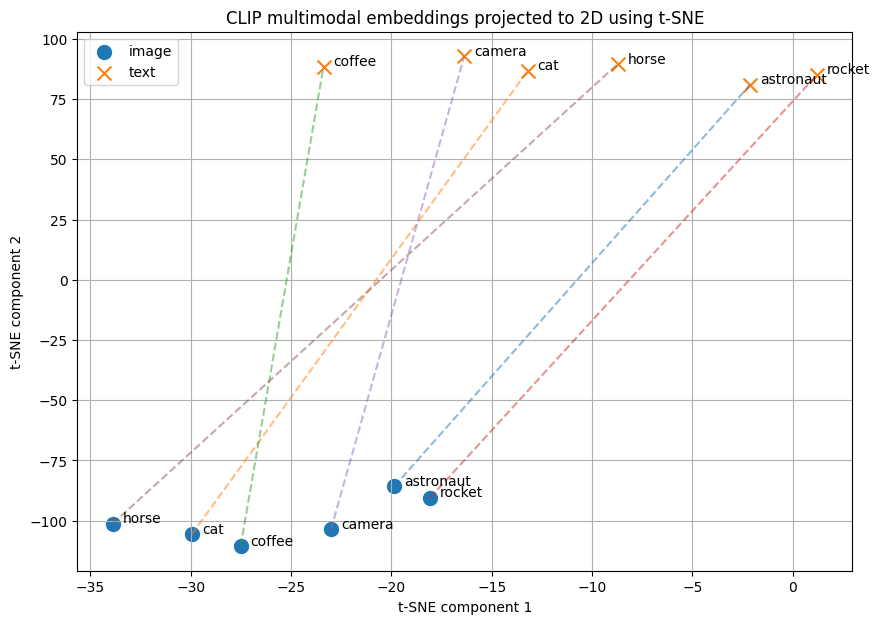

In [14]:
plt.figure(figsize=(10, 7))

for item_type, marker in [("image", "o"), ("text", "x")]:
    subset = tsne_df[tsne_df["type"] == item_type]
    
    plt.scatter(
        subset["x"],
        subset["y"],
        marker=marker,
        s=100,
        label=item_type
    )
    
    for _, row in subset.iterrows():
        plt.text(row["x"] + 0.5, row["y"] + 0.5, row["label"])

for i in range(len(image_data)):
    image_point = tsne_df.iloc[i]
    text_point = tsne_df.iloc[i + len(image_data)]
    
    plt.plot(
        [image_point["x"], text_point["x"]],
        [image_point["y"], text_point["y"]],
        linestyle="--",
        alpha=0.5
    )

plt.title("CLIP multimodal embeddings projected to 2D using t-SNE")
plt.xlabel("t-SNE component 1")
plt.ylabel("t-SNE component 2")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
accuracy_text_to_image = text_to_image_df["correct"].mean()
accuracy_image_to_text = image_to_text_df["correct"].mean()

print("Accuracy texto → imagen:", accuracy_text_to_image)
print("Accuracy imagen → texto:", accuracy_image_to_text)

Accuracy texto → imagen: 1.0
Accuracy imagen → texto: 1.0


## Conclusión

En este ejercicio se utilizaron embeddings multimodales generados con CLIP. Primero se construyó un pequeño conjunto de imágenes y textos asociados. Luego, el modelo CLIP generó embeddings para ambos tipos de datos.

Se verificó que los embeddings de imágenes y textos tienen la misma dimensión, lo que permite compararlos directamente mediante similitud coseno. Después, se construyó una matriz de similitud para evaluar búsquedas texto→imagen e imagen→texto.

Finalmente, los vectores se proyectaron a dos dimensiones usando PCA y t-SNE. En las gráficas se puede observar cómo imágenes y textos relacionados tienden a ubicarse cerca dentro del espacio vectorial proyectado. Esto demuestra que CLIP representa información visual y textual en un espacio compartido, permitiendo tareas de búsqueda y comparación multimodal.